In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta


In [2]:
df = pd.read_csv("sales_data_sample.csv", encoding='latin1')

In [3]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [4]:
df.shape

(2823, 25)

In [6]:
df.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='str')

In [8]:
df.dtypes

ORDERNUMBER           int64
QUANTITYORDERED       int64
PRICEEACH           float64
ORDERLINENUMBER       int64
SALES               float64
ORDERDATE               str
STATUS                  str
QTR_ID                int64
MONTH_ID              int64
YEAR_ID               int64
PRODUCTLINE             str
MSRP                  int64
PRODUCTCODE             str
CUSTOMERNAME            str
PHONE                   str
ADDRESSLINE1            str
ADDRESSLINE2            str
CITY                    str
STATE                   str
POSTALCODE              str
COUNTRY                 str
TERRITORY               str
CONTACTLASTNAME         str
CONTACTFIRSTNAME        str
DEALSIZE                str
dtype: object

In [9]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   str    
 6   STATUS            2823 non-null   str    
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   str    
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   str    
 13  CUSTOMERNAME      2823 non-null   str    
 14  PHONE             2823 non-null   str    
 15  ADDRESSLINE1      2823 non-null   str    
 16  ADDRESSLINE2      302 non-null    str    
 17  CITY  

In [12]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])
print("en köhne tarix:", df['ORDERDATE'].min())
print("en yeni tarix:", df['ORDERDATE'].max())

en köhne tarix: 2003-01-06 00:00:00
en yeni tarix: 2005-05-31 00:00:00


In [13]:
reference_date = df['ORDERDATE'].max() + timedelta(days=1)
print("Referans tarix:", reference_date) #referans

Referans tarix: 2005-06-01 00:00:00


In [ ]:
rfm = df.groupby('CUSTOMERNAME').agg({
    'ORDERDATE': lambda x: (reference_date - x.max()).days,#nece gun kecdiyi
    'ORDERNUMBER': 'nunique',
    'SALES': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CUSTOMERNAME,,,
"AV Stores, Co.",196,3,157807.81
Alpha Cognac,65,3,70488.44
Amica Models & Co.,265,2,94117.26
"Anna's Decorations, Ltd",84,4,153996.13
Atelier graphique,188,3,24179.96


In [16]:
rfm.describe()

,Recency,Frequency,Monetary
count,92.000000,92.000000,92.000000
mean,182.826087,3.336957,109050.313587
std,131.420524,2.924986,110308.612808
min,1.000000,1.000000,9129.350000
25%,81.250000,2.000000,70129.432500
50%,186.000000,3.000000,86522.610000
75%,230.250000,3.000000,120575.875000
max,509.000000,26.000000,912294.110000


In [18]:
# Recency skoru
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1])
# Frequency skoru
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4])
# Monetary skoru
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4])
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CUSTOMERNAME,,,,,,
"AV Stores, Co.",196,3,157807.81,2,2,4
Alpha Cognac,65,3,70488.44,4,2,2
Amica Models & Co.,265,2,94117.26,1,1,3
"Anna's Decorations, Ltd",84,4,153996.13,3,4,4
Atelier graphique,188,3,24179.96,2,2,1


In [20]:
rfm['RFM_Segment'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str))
rfm.head() #seqment ucun

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
CUSTOMERNAME,,,,,,,
"AV Stores, Co.",196,3,157807.81,2,2,4,224
Alpha Cognac,65,3,70488.44,4,2,2,422
Amica Models & Co.,265,2,94117.26,1,1,3,113
"Anna's Decorations, Ltd",84,4,153996.13,3,4,4,344
Atelier graphique,188,3,24179.96,2,2,1,221


In [21]:
def segment_me(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    if r == 4 and f == 4 and m == 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r == 1 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r == 2 and f >= 2:
        return 'Need Attention'
    elif r == 1 and f == 1:
        return 'Lost'
    else:
        return 'Others'
rfm['Segment'] = rfm.apply(segment_me, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,Segment
CUSTOMERNAME,,,,,,,,
"AV Stores, Co.",196,3,157807.81,2,2,4,224,Need Attention
Alpha Cognac,65,3,70488.44,4,2,2,422,Others
Amica Models & Co.,265,2,94117.26,1,1,3,113,Lost
"Anna's Decorations, Ltd",84,4,153996.13,3,4,4,344,Loyal Customers
Atelier graphique,188,3,24179.96,2,2,1,221,Need Attention


In [22]:
segment_summary = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Segment': 'count'
}).rename(columns={
    'Segment': 'Customer_Count',
    'Recency': 'Avg_Recency',
    'Frequency': 'Avg_Frequency',
    'Monetary': 'Avg_Monetary'
})
segment_summary = segment_summary.sort_values(
    by='Avg_Monetary',
    ascending=False
)
segment_summary

,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Count
Segment,,,,
Champions,19.444444,8.111111,290097.736667,9
At Risk,456.000000,3.000000,142874.250000,1
Loyal Customers,101.769231,3.423077,111308.429615,26
Need Attention,201.333333,3.111111,99222.925556,18
Others,191.761905,2.523810,72066.690952,21
Lost,346.588235,1.941176,63849.566471,17


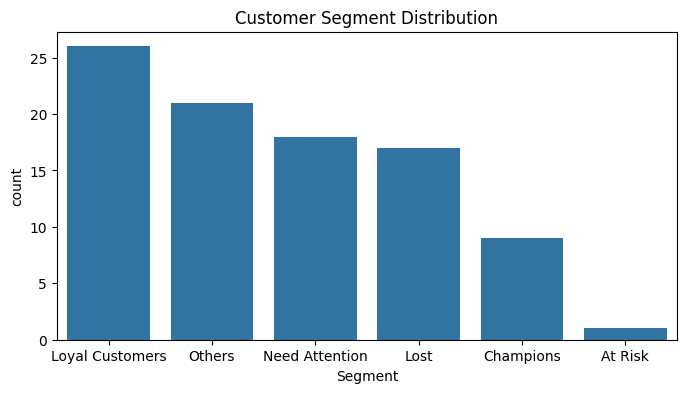

In [28]:
plt.figure(figsize=(8,4))
sns.countplot(
    data=rfm,
    x='Segment',
    order=rfm['Segment'].value_counts().index
)
plt.title("Customer Segment Distribution")
plt.xticks(rotation=0)
plt.show()

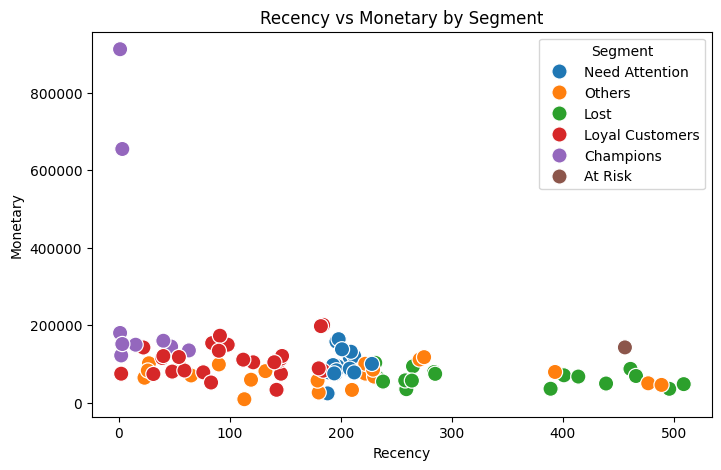

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    s=120)
plt.title("Recency vs Monetary by Segment")
plt.show()

In [34]:
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

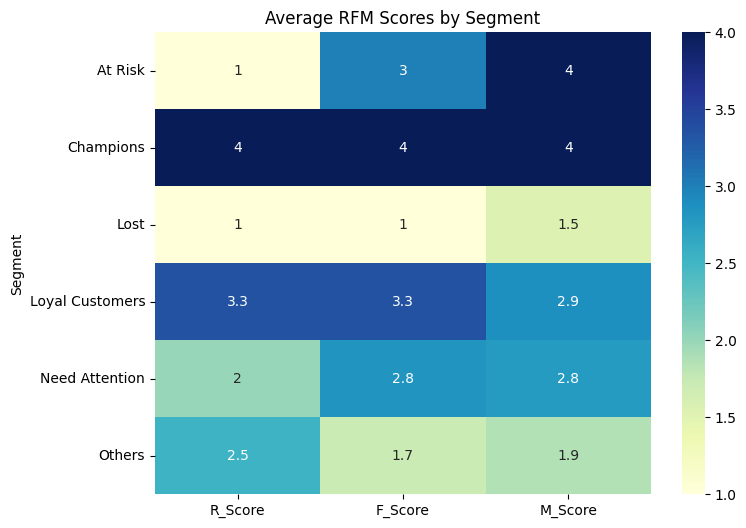

In [36]:
heatmap_data = rfm.groupby('Segment')[[
    'R_Score',
    'F_Score',
    'M_Score']].mean()
plt.figure(figsize=(8,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='YlGnBu')
plt.title("Average RFM Scores by Segment")
plt.show()

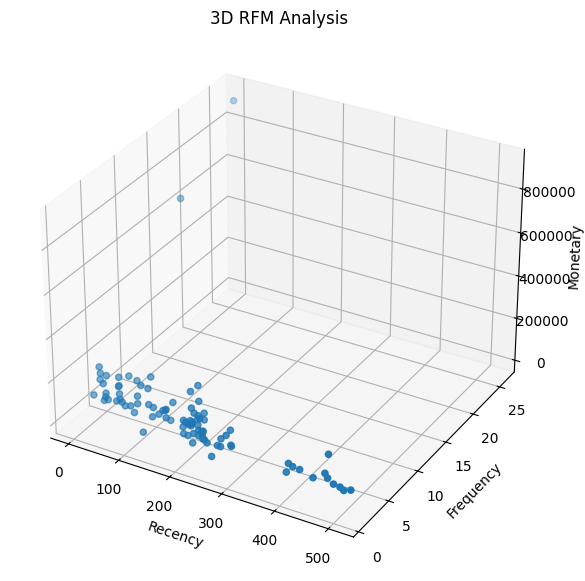

In [39]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    rfm['Monetary'])
ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.title("3D RFM Analysis")
plt.show()

In [40]:
rfm.to_csv("RFM_Customer_Segmentation.csv")
print("CSV faylı yaradıldı")

CSV faylı yaradıldı
